# Graphical models, dynamic programming, and message passing


In most systems with many constituents, direct interactions are restricted to subsets of pairs of variables, or sometimes larger groups of variables. This has been explicit on physics inspired models like the Ising model, where the energy of the system was given by
$$
E(\vec{\sigma}) = -\sum_i h_i \sigma_i - \sum_{i<j} J_{ij}\sigma_i\sigma_j
$$
Each $h_i$ parameterizes in interaction with an external field, and all non-zero $J_{ij}$ are pair interaction between spins $i$ and $j$. This energy corresponds to a Boltzmann distribution
$$
P(\vec{\sigma}) = Z^{-1} e^{-E(\vec{\sigma})/kT}
$$
The sum over many individuals terms in the energy obviously correspond to factors of a big product of function $f_i(\sigma_i) = e^{-h_i \sigma_i}$ and $f_{ij}(\sigma_i, \sigma_j) =e^{-J_{ij}\sigma_i\sigma_j}$ where higher order interactions can be accommodated analogously. 

To make this structure explicit, models are often formulated as _Factor Graphs_ 

## Factor graphs
Factor graphs are bi-partite graphs where one type of nodes correspond to the variables, and the other type is called function nodes that describe the contribution to the probability of the encoded interactions between variables it is connecting.   
![factor_graphs](figures/factor_graphs.png)

There is nothing fundamental in these graphs themselves, they are merely a convenient way of reasoning about models that describe the probability of the system in terms of functions of subsets of the variables. This probility can be written as a produced over all function nodes $a\in [\cdots]$ with $\vec{x}_{\partial_a}$ denoting the set of variables nodes that are adjacent to function node $a$:
$$
P(\vec{x})  = Z^{-1} \prod_a f_a(\vec{x}_{\partial_a})
$$
with 
$$
Z = \sum_{\vec{x}} \prod_a f_a(\vec{x}_{\partial_a})
$$
Note that the product of functions is equivalent to a sum of terms in the energy. 


# Efficient calculations on trees
Whenever the factor graph is a tree, i.e. whenever it does not have cycles, the partion sum can be calculated exactly in linear time. 

## Example: Ising chain
Consider the 1-d Ising model as a simple example:
![ising](figures/ising_chain.png)
This factor graph corresponds to the Energy
$$
E(\vec{\sigma}) = -h\sum_i \sigma_i - J\sum_{i} \sigma_i\sigma_{i+1}
$$
and you have solved this already via the transfer matrix method as an exercise. 


Using this example of the Ising model, we want to introduce a generic method to calculate partition sums and marginal distribution of tree-like graphical models. To this end, define the _messages_ $\hat{\nu}_{i\leftarrow}(\sigma_i)$ and $\hat{\nu}_{i\rightarrow}(\sigma_i)$:
$$
\begin{split}
\hat{\nu}_{i\leftarrow}(\sigma_i) & \sim \sum_{\sigma_{i+1}\ldots \sigma_N} e^{h\sum_{j=i+1}^N \sigma_j + J \sum_{j=i}^{N-1} \sigma_j\sigma_{j+1}} \\
\hat{\nu}_{i\rightarrow}(\sigma_i) & \sim \sum_{\sigma_{1}\ldots \sigma_{i-1}} e^{h\sum_{j=1}^{i-1} \sigma_j + J \sum_{j=1}^{i-1} \sigma_j\sigma_{j+1}} \\
\end{split}
$$
These "messages" are functions of the focal variable $\sigma_i$ only, but still need normalization. For this purpose, note that they can be calculated recursively. 
$$
\hat{\nu}_{i\leftarrow}(\sigma_i) = \frac{1}{z_i}\sum_{\sigma_{i+1}} e^{h\sigma_{i+1} + J\sigma_{i}\sigma_{i+1}}\hat{\nu}_{i+1\leftarrow}(\sigma_{i+1})
$$
where $z_i$ is the normalization at step $i$. The above is exactly the transfer matrix calculation that we alluded to before, but these message allow for compact intuitive notatation and generalizations. 
The marginal distribution at node $i$ is for example simply 
$$
\mu(\sigma_i) = \frac{1}{z}\hat{\nu}_{i\rightarrow}(\sigma_i)e^{h\sigma_i}\hat{\nu}_{i\leftarrow}(\sigma_i)
$$
which can be interpreted as product of coupling to spins on the left and right and the local effect.  


## Conditional independence
The ability to recursively calculate the message and the partition sum is related to the property of conditional independence. In a tree, whenever you fix a variable at a certain node, the different subtrees emanating for the fixed node are now independent. More generally, if a set of nodes $S$ separates two sets of nodes $A$ and $B$ on in a factor graph (in the sense that taking out set $S$ removes all paths from $A$ to $B$), then 
$$
P(\vec{x}_A,\vec{x}_B | \vec{x}_S) = P(\vec{x}_A | \vec{x}_S)P(\vec{x}_B | \vec{x}_S)
$$
The number of steps necessary to calculate $P(\vec{x}_A,\vec{x}_B | \vec{x}_S)$ is thus not the cardinality of $|\vec{x}_{A+B}|=|\vec{x}_A|\times|\vec{x}_B|$, but $|\vec{x}_A|+|\vec{x}_B|$. 

## Belief propagation on trees
In the Ising chain above, all function nodes have only two arguments and the topology of the model is a line. On more general tree-like graphs, function nodes can have more than two inputs. Likewise, a variable node can be connected to many function nodes. To accomodate this more general situation, it is helpful to introduce two kind of message $\nu_{i\rightarrow a}$ from variable nodes to function nodes and $\hat{\nu}_{a\rightarrow i}$ from function nodes to variable nodes. We can now define a recursion on the tree-like graph, where starting at the tips of the tree, we calculate message as 
$$
\begin{split}
\nu_{i\rightarrow c}(x_i) & \sim  \prod_{a\in \partial_i\backslash c} \hat{\nu}_{a\rightarrow i}(x_i)\\
\hat{\nu}_{a\rightarrow i}(x_i) & \sim \sum_{\vec{x}_{\partial_a\backslash i}} f_a(\vec{x}_{\partial_a}) \prod_{k\in \partial_a\backslash i} \nu_{k\rightarrow a}(x_k)
\end{split}
$$
The sum $\sum_{\vec{x}_{\partial_a\backslash i}}$ sums over all variable nodes "upstream" of function $a$ while the variable $x_i$ is kept fixed. 

![BP_messages](figures/BP_messages.png)

Starting these recursions at the tips of the graph and working your way through, in one interation one can calculate all messages on all edges of the graph. This gives immediate access to all marginals 
$$
\mu(x_i) \sim \prod_{a \in \partial_i} \hat{\nu}_{a\rightarrow i}(x_i)
$$
where the appropriate normalization is easy to compute. 



### Repeated discovery
This technique of efficient marginalization on tree-like graphs has been discovered in repeatedly in many fields. It is known for example as 

 - [Dynamic programming](https://en.wikipedia.org/wiki/Dynamic_programming), a term popularized by Richard Bellmann. Dynamic programming terminology is for example used to solve sequence alignment problems.
 - Transfer matrix in physics
 - Felsenstein's pruning algorithm to calculate likelihood on phylogenetic trees
 - Sum-product rule in coding theory


### Random initialization and iteration
It can be shown that if all messages $\nu_{i\to a}$ are initialized at random and iterated as 
$$
\begin{split}
\hat{\nu}^t_{a\rightarrow i}(x_i) & \sim \sum_{\vec{x}_{\partial_a\backslash i}} f_a(\vec{x}_{\partial_a}) \prod_{k\in \partial_a\backslash i} \nu^t_{k\rightarrow a}(x_k) \\
\nu^{t+1}_{i\rightarrow c} & \sim  \prod_{a\in \partial_i\backslash c} \hat{\nu}^t_{a\rightarrow i}(x_i)
\end{split}
$$
this iteration will converge within a number of steps given by the maximial diameter of the graph. The result is the exact post-order traversal result above. 

### Multi-point marginals
The marginal distribution of a single variable can be expressed completely locally in terms of incoming messages. Similarly, we can express joint distribution $\mu(x_i, x_j)$ of multiple variables. A two point function, for example, splits a tree like graph into three parts: two outside parts, for which the incoming messages can be used as is, and a path between the nodes in question. Along this path connecting the nodes, we need to recalculate the messages conditioning on the value of one of the two nodes. 





## Example

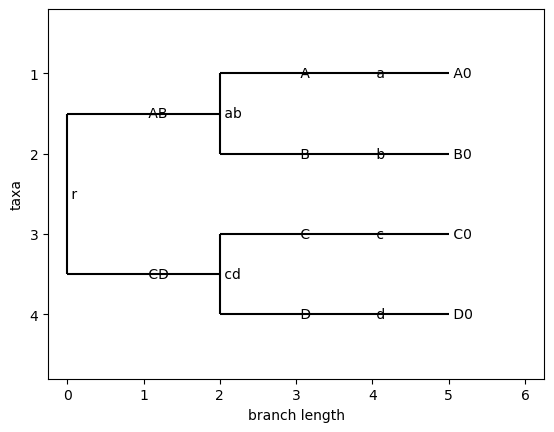

In [4]:
import numpy as np
from Bio import Phylo
from io import StringIO

# each lowercase letter is variable node, each upper case letter a function node. 
T = Phylo.read(StringIO('(((((A0)a)A,((B0)b)B)ab)AB,((((C0)c)C,((D0)d)D)cd)CD)r;'), 'newick');
Phylo.draw(T)

# for simplicity, lets consider the state space x in [0,1] and make all functions e^{J_a (sum_j x_j)%2} 
# where J_a is a fixed random number
for node in T.find_clades(order='preorder'):
    for c in node.clades:
        c.parent = node
    if node.name[0].upper()==node.name[0]:
        node.node_type = 'function'
        node.J = np.random.random()
        node.f = lambda x: np.exp(-node.J*np.sum(x)%2)
    else:
        node.node_type = 'variable'
        node.states = [0,1]

In [5]:
from itertools import product

# post-order (leaf-to-root) traversal
for node in T.find_clades(order='postorder'):
    if node.node_type=='function':
        msg_to_parent = []
        states = list(product(*[c.states for c in node]))
        if len(states)==0:
            states = [[]]
        for pstate in node.parent.states:
            tmp = 0
            for cstates in states:
                p = np.prod([c.msg_to_parent[i] for i,c in zip(cstates, node.clades)])
                tmp += node.f([pstate] + list(cstates))*p
            msg_to_parent.append(tmp)
    else:
        msg_to_parent = np.ones(len(node.states))
        for c in node:
            msg_to_parent *= c.msg_to_parent
    node.msg_to_parent = np.array(msg_to_parent)/np.sum(msg_to_parent)
                
T.root.marginal = np.prod([c.msg_to_parent for c in node], axis=0)
tmp = T.root.marginal.sum()
T.root.marginal /= tmp
print(T.root.marginal)

[0.18950219 0.81049781]


In [6]:
# pre-order (root to children)
for node in T.find_clades(order='preorder'):
    if node.node_type=='function':
        #todo
        pass
    else:
        for c1 in node:
            msg_to_child = np.ones(len(node.states)) if node==T.root else np.copy(node.parent.msg_to_child)
            for c2 in node:
                if c2!=c1:
                    msg_to_child *= c2.msg_to_parent

            c1.msg_to_child = msg_to_child/np.sum(msg_to_child)
    


## Energies and Entropies of tree-like graphical models

As discussed above, each function node of the graph can be interpreted as a contribution to the energy 
$$
U_a(\vec{x}_{\partial a}) = -kT \log f_a(\vec{x}_{\partial a}) + c
$$
The expectation value of the total energy $U(\vec{x}) = \sum_a U_a(\vec{x}_{\partial a})$ can be expressed in terms of the messages we calculated above. 
$$
\langle U_a(\vec{x}_{\partial a}) \rangle = -kT \sum_{\vec{x}_{\partial a}} \mu(\vec{x}_{\partial a})\log f_a(\vec{x}_{\partial a})= -\frac{kT}{Z_a} \sum_{\vec{x}_{\partial a}}f_a(\vec{x}_{\partial a}) \log \left(f_a(\vec{x}_{\partial a}) \right) \prod_{i\in \partial_a} \nu_{i\to a}(x_i)
$$
The last equality used that the joint distribution of the states surrounding the function node $a$ is given by the product of the incoming messages and the function $f_a$ itself. Once the messages are calculated, evaluation of the energy is thus a local computation. 


### Joint distribution of variable nodes
The joint distribution of all variable nodes $\vec{x}$ can be expressed as a product of marginals:
$$
\mu(\vec{x}) = \prod_{a} \mu_a(\vec{x}_{\partial_a}) \prod_{i} \mu_i(x_i)^{1-|\partial_i|}
$$
This formula can be proved by induction. If there is only one function node ($M=1$) all variable nodes connected to this function nodes have $|\partial_i|=1$ (they are connected to the only node). Hence the second product is trivial and the equation holds.  
Now consider a graph with $M+1$ nodes and single out a "pre-terminal" factor $a$ with at most one variable $i$ with degree $>1$.
In this situation, we are considering two sets of nodes: $\partial_a\backslash i$ and the remainder $g$. We can write
$$
\mu(\vec{x}) = p(\vec{x}_g)p(\vec{x}|\vec{x}_g) = p(\vec{x}_g)p(\vec{x}_{\partial_a \backslash i}|x_i)
$$
The last step is true because $\partial_a \backslash i$ is independent of $g$ after conditioning on $i$. The set of variables $g$ forms a factor graph of $M$ nodes for which the assumption is true. The conditional probability is
$$
p(\vec{x}_{\partial_a \backslash i}|x_i) = \frac{p(\vec{x}_{\partial_a})}{p(x_i)} = \frac{\mu_a(\vec{x}_{\partial_a})}{\mu_i(x_i)}. 
$$
The above decomposition of the graph with $M+1$ factors into one with $M$ and an additional factor therefore adds the marginal distribution of the additional factor $\mu_a(\vec{x}_{\partial_a})$ and divides by the marginal distribution of the connecting variable node.

One way to inuitively rationalize this distribution is the following. Each term $\mu_a(\vec{x}_{\partial_a})$ is the joint marginal distribution of all nodes $i$ adjacent to $a$ and therefore contains a contribution for each of its adjacent variable nodes $i$. If a node $i$ is adjancent to more than one factor node $a$, we have to avoid accounting for its contribution to the distribution multiple times, which is accomplished by the factor $\mu_i(x_i)^{1-|\partial i|}$.

## Entropy
The entropy is simply $S = -\sum_{\vec{x}} \mu(\vec{x})\log \mu(\vec{x})$ which reduces to a convenient expression that can be evaluated locally:
$$
S = -\sum_a \sum_{\vec{x}_{\partial_a}} \mu_a(\vec{x}_{\partial_a}) \log(\mu_a(\vec{x}_{\partial_a})) - \sum_i (1-|\partial_i|) \sum_{x_i} \mu_i(x_i) \log \mu_i(x_i) 
$$

Together with the average of the energy, one can express the free energy of a tree-like graphical model purely in terms of local messages. 

For details of the calculations, we refer to the [book "Information, Physics, Computation"](https://web.stanford.edu/~montanar/RESEARCH/book.html) by Montanari and Mezard.


# Loopy belief propagation

The iterative update rules can in principle by be interated on any graph, not just on tree graphs. And while in general there is no guarantee of convergence, in practice this iteration often converges well and if so often to a good approximation of the true distribution. 

### Bethe Free Energy
We have seen above that the global distribution of the variable distribution of a tree-like model can be expressed in terms of local marginals. The Bethe approximation to the free energy is an analogous construction of the full distribution using local marginals. It can be shown that this Bethe solution is a fixpoint of the belief propagation update rules. 
This expression in terms of marginals ignores correlations induced by loops. 

This observations gives some intuition when message passing on loop graphs is expected to yield accurate results: On a tree, fixing or removing one node results in independent sub-problems. In many real-world problems, the resulting graphical model is not tree-like, but loops are long. As a result, variable in the neighborhood of a node $i$ are still only weakly correlated if node $i$ is fixed or removed. 

![loopy_BP](figures/non-tree_BP.png)





# Moment closures

Consider the equation for a population density $P(x,t)$ along a coordinate $x$:
$$
\frac{d P(x,t)}{dt} = (x - \langle x\rangle(t))P(x,t)
$$
where $\langle x\rangle = \int xP(x,t)\, dx$ is required to keep the density constant. This equation could for example describe the evolution of a population of individuals with fitness $x$, where $x-\langle x\rangle$ is the relative growth rate of individuals with fitness $x$.

The time derivative of the mean fitness $\langle x\rangle$ is given by 
$$
\frac{d \langle x\rangle}{dt} = \int x\frac{d P(x,t)}{dt}\, dx = \int x (x - \langle x\rangle(t))P(x,t) \, dx= \sigma^2(t)
$$
We thus see that the evolution of the mean is determined by the variance. Similarly, the evolution of the variance is coupled to higher moments of the distribution:
$$
\frac{d \sigma^2}{dt} = \int x(x-\langle x\rangle)^2 P(x,t) \, dx - \langle x\rangle\sigma^2 = \langle (x-\langle x\rangle)^3 \rangle
$$
This pattern continues: The dynamics of a particular moment depends on higher moments.


In fact, it is straightforward to show that for every cumulant $k_n$, the above equation implies the evolution $d\kappa_n/dt = \kappa_{n+1}$ for all $n>0$. This is readily shown using the cumulant generating function:
$$
C(s,t) = \log(\int dx e^{sx}P(x,t)) = \log M(s,t) = \sum_n \kappa_n \frac{s^n}{n!}
$$
where $M$ is the moment generating function.
The time derivative of this equation is 
$$
\begin{split}
\frac{d}{dt}C(s,t) & = M^{-1} \int dx e^{sx}\frac{dP(x,t)}{dt} = M^{-1}\int dx e^{sx} (x - \langle x\rangle) P(x,t) \\ 
& = C^{-1} \frac{d}{ds} \int dz e^{sx}P(x,t) - \langle x\rangle = \frac{d}{ds} \log M  - \langle x\rangle = \frac{d}{ds} C  - \langle x\rangle 
\end{split}
$$
We can now match terms of equal powers of $s$:
$$
\sum_n \frac{d\kappa_n}{dt} \frac{s^n}{n!} = \sum_{n>0} \kappa_{n+1} \frac{s^n}{n!}
$$
from which immediately follows $d\kappa_n/dt = \kappa_{n+1}$. We thus see that the original equation for the probability distribution corresponds to an infinite hierarchy of equations for the moments of cumulants. 


## Truncating the moment hierarchies

If, however, there are reasons why central higher order moments (or cumulants) decay, such systems can be solved approximately by expressing higher order moments through lower orders.

The example above is solved by 
$$
P(x,t) = \frac{1}{\sqrt{2\pi \sigma^2}}e^{-\frac{(x-\sigma^2t)^2}{2\sigma^2}}
$$
The third and higher order cumulants of the Gaussian are zero such that $\sigma^2$ is constant, but whether this solution is stable is unclear. 

In fact, this solution is unrealistic since the entire $x$-axis is assumed to be populated from the beginning by minute densities that get amplified over time. In practice, the population occupies a finite range and new genotypes need to be generated by mutation and recombination, see for example [Neher and Shraiman](https://link.aps.org/doi/10.1103/RevModPhys.83.1283) for a review. The stochastic dynamics generates contributions to higher order cumulants and the solution ceases to be a perfect Gaussian. 
Truncation or closure of such moment hierarchies are possible if there are contributions to the equation that cause higher order moments to decay.

In population genetics, a very process that is very effective at destroying correlations is recombination. 
In a simple example, we could for example assume a recombination process where every generation a fraction $r$ of the population is replaced by offspring that are drawn from a Gaussian with mean $\langle x\rangle$ and variance $\rho^2$:

$$
\frac{d P(x,t)}{dt} = (x - \langle x\rangle(t))P(x,t) + r\frac{e^{-\frac{(x-\langle x\rangle)^2}{2\rho^2}}}{\sqrt{2\pi\rho^2}} - rP(x,t)
$$
(a slightly more complex scenario where two parents are drawn at random from the distribution is presented as exercise).

When looking at moments of this distribution, we immediately see that the first moment is unaffected:
$$
\frac{d \langle x\rangle}{dt} = \int x (x - \langle x\rangle(t))P(x,t) \, dx= \sigma^2(t)
$$
The second moment, however, is affected by the recombination term:
$$
\frac{d \sigma^2}{dt} =  \langle (x-\langle x\rangle)^3 \rangle + r(\rho^2 - \sigma^2)
$$
The recombination term drives this term towards $\rho^2$ and there will be a balance betweem the two terms on the right hand side. 
$$
\sigma^2 \approx \rho^2 + r^{-1} \langle (x-\langle x\rangle)^3 \rangle
$$
The third moment is 
$$
\frac{d \langle (x-\langle x\rangle)^3\rangle }{dt} =  \langle (x-\langle x\rangle)^4 \rangle - 3\sigma^4 - r \langle (x-\langle x\rangle)^3 = \kappa_4 - r \langle (x-\langle x\rangle)^3\rangle
$$
where $\kappa_4$ is the fourth cumulant. We thus see that the third moment is fed by the fourth cumulant and decays with rate $r$. An approximate steady state solution is
$$
\langle (x-\langle x\rangle)^3\rangle \approx r^{-1} \kappa_4
$$
